In [5]:
import os

print(os.getcwd())
print(os.listdir())

/Users/saraelbachouti/Desktop/UCV-Churn
['eda5.ipynb', 'primermodelosimple.ipynb', '.DS_Store', 'LICENSE', 'requirements.txt', 'tercermodelo.ipynb', 'modelomasexacto.ipynb', 'config', 'Dockerfile', 'eda4.ipynb', 'edatercerenfoque.ipynb', 'models', 'docs', 'README.md', 'cuartomodelo.ipynb', '.gitignore', 'edasegundoenfoque.ipynb', 'dataset_limpio_churn.csv', '.git', 'processed', 'data', 'edaprimerenfoque.ipynb', 'notebooks', 'reports', 'src']


In [3]:
# ============================================================
# MODELO FINAL XGBOOST MEJORADO (VERSIÓN QUE FUNCIONA)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# ============================================================
# 1. CARGAR DATASET YA EXISTENTE
# ============================================================

if "df_model" in globals():

    dataset = df_model.copy()

elif "df" in globals():

    dataset = df.copy()

else:

    raise Exception(
        """
ERROR:
No existe ni df ni df_model.

Ejecuta primero la celda donde construyes el dataset.
"""
    )

print("Shape inicial:", dataset.shape)


# ============================================================
# 2. FECHA
# ============================================================

if "fecha" in dataset.columns:

    dataset["fecha"] = pd.to_datetime(
        dataset["fecha"],
        errors="coerce"
    )

    if "cliente_id" in dataset.columns:

        dataset = dataset.sort_values(
            [
                "cliente_id",
                "fecha"
            ]
        )


# ============================================================
# 3. FEATURES TEMPORALES
# ============================================================

if "cliente_id" in dataset.columns:

    if "importe_total" in dataset.columns:

        dataset["media_importe_3m"] = (
            dataset
            .groupby("cliente_id")
            ["importe_total"]
            .transform(
                lambda x:
                x.rolling(
                    3,
                    min_periods=1
                ).mean()
            )
        )

        dataset["importe_mes_anterior"] = (
            dataset
            .groupby("cliente_id")
            ["importe_total"]
            .shift(1)
        )

        dataset["subida_factura"] = (
            dataset["importe_total"]
            -
            dataset["importe_mes_anterior"]
        )


    if "dias_retraso_pago" in dataset.columns:

        dataset["media_retraso_3m"] = (

            dataset
            .groupby("cliente_id")
            ["dias_retraso_pago"]

            .transform(
                lambda x:
                x.rolling(
                    3,
                    min_periods=1
                ).mean()
            )
        )


    if "impago_flag" in dataset.columns:

        dataset["impagos_3m"] = (

            dataset
            .groupby("cliente_id")
            ["impago_flag"]

            .transform(
                lambda x:
                x.rolling(
                    3,
                    min_periods=1
                ).sum()
            )
        )


# ============================================================
# 4. VARIABLES INTERACCIÓN
# ============================================================

if (
    "dias_retraso_pago"
    in dataset.columns
    and
    "importe_total"
    in dataset.columns
):

    dataset["riesgo_pago"] = (
        dataset["dias_retraso_pago"]
        *
        dataset["importe_total"]
    )


if (
    "impago_flag"
    in dataset.columns
    and
    "stress_calidad_lag"
    in dataset.columns
):

    dataset["riesgo_finanzas"] = (

        dataset["impago_flag"]

        *

        dataset["stress_calidad_lag"]

    )


# ============================================================
# 5. ELIMINAR COLUMNAS
# ============================================================

eliminar = [

    "cliente_id",

    "fecha",

    "zona_id",

    "zona_id_x",

    "zona_id_y"

]

dataset = dataset.drop(

    columns=[

        c

        for c

        in eliminar

        if c

        in dataset.columns

    ],

    errors="ignore"

)


# ============================================================
# 6. TARGET
# ============================================================

X = dataset.drop(

    columns="churn"

)

y = dataset["churn"]


# ============================================================
# 7. CATEGÓRICAS
# ============================================================

X = pd.get_dummies(

    X,

    drop_first=True

)


# ============================================================
# 8. LIMPIEZA
# ============================================================

X = X.replace(

    [np.inf, -np.inf],

    np.nan

)

X = X.fillna(

    X.median(

        numeric_only=True

    )

)


# ============================================================
# 9. TRAIN TEST
# ============================================================

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,

        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

)


# ============================================================
# 10. PESO
# ============================================================

peso = (

    (y_train == 0).sum()

    /

    (y_train == 1).sum()

)

print("scale_pos_weight:", round(peso,2))


# ============================================================
# 11. XGBOOST
# ============================================================

modelo = XGBClassifier(

    n_estimators=800,

    learning_rate=0.03,

    max_depth=4,

    min_child_weight=12,

    gamma=2,

    subsample=0.85,

    colsample_bytree=0.80,

    reg_alpha=2,

    reg_lambda=6,

    scale_pos_weight=peso,

    random_state=42,

    eval_metric="logloss",

    n_jobs=-1

)

modelo.fit(

    X_train,

    y_train

)


# ============================================================
# 12. PROBA
# ============================================================

proba = (

    modelo

    .predict_proba(

        X_test

    )[:,1]

)


# ============================================================
# 13. THRESHOLD
# ============================================================

mejor_f1 = 0

threshold_final = 0.5


for t in np.arange(

    0.10,

    0.81,

    0.01

):

    pred = (

        proba >= t

    ).astype(int)

    f1 = f1_score(

        y_test,

        pred,

        zero_division=0

    )

    if f1 > mejor_f1:

        mejor_f1 = f1

        threshold_final = t


pred = (

    proba >= threshold_final

).astype(int)


# ============================================================
# RESULTADOS
# ============================================================

print("\n"+"="*70)

print(
"RESULTADOS MODELO FINAL"
)

print("="*70)

print(
"Threshold utilizado:",
round(
threshold_final,
2
)
)

print(
"Accuracy:",
round(
accuracy_score(
y_test,
pred
)
*100,
2
)
)

print(
"Precision:",
round(
precision_score(
y_test,
pred,
zero_division=0
),
4
)
)

print(
"Recall:",
round(
recall_score(
y_test,
pred
),
4
)
)

print(
"F1:",
round(
f1_score(
y_test,
pred
),
4
)
)

print(
"ROC:",
round(
roc_auc_score(
y_test,
proba
),
4
)
)

print(
"PR:",
round(
average_precision_score(
y_test,
proba
),
4
)
)

print(

confusion_matrix(
y_test,
pred
)

)

Exception: 
ERROR:
No existe ni df ni df_model.

Ejecuta primero la celda donde construyes el dataset.


In [6]:
# ============================================================
# MODELO FINAL XGBOOST CORRECTO
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# ============================================================
# 1. CARGAR DATASET
# ============================================================

df_model = pd.read_csv("dataset_limpio_churn.csv")

dataset = df_model.copy()

print("Shape inicial:", dataset.shape)


# ============================================================
# 2. FECHAS
# ============================================================

if "fecha" in dataset.columns:

    dataset["fecha"] = pd.to_datetime(
        dataset["fecha"],
        errors="coerce"
    )

    if "cliente_id" in dataset.columns:

        dataset = dataset.sort_values(
            ["cliente_id", "fecha"]
        )


# ============================================================
# 3. FEATURES TEMPORALES
# ============================================================

if (
    "cliente_id" in dataset.columns
    and
    "importe_total" in dataset.columns
):

    dataset["media_importe_3m"] = (
        dataset
        .groupby("cliente_id")["importe_total"]
        .transform(
            lambda x:
            x.rolling(
                3,
                min_periods=1
            ).mean()
        )
    )

    dataset["importe_mes_anterior"] = (
        dataset
        .groupby("cliente_id")
        ["importe_total"]
        .shift(1)
    )

    dataset["subida_factura"] = (
        dataset["importe_total"]
        -
        dataset["importe_mes_anterior"]
    )


if (
    "cliente_id" in dataset.columns
    and
    "dias_retraso_pago" in dataset.columns
):

    dataset["media_retraso_3m"] = (

        dataset

        .groupby("cliente_id")

        ["dias_retraso_pago"]

        .transform(
            lambda x:
            x.rolling(
                3,
                min_periods=1
            ).mean()
        )
    )


if (
    "cliente_id" in dataset.columns
    and
    "impago_flag" in dataset.columns
):

    dataset["impagos_3m"] = (

        dataset

        .groupby("cliente_id")

        ["impago_flag"]

        .transform(
            lambda x:
            x.rolling(
                3,
                min_periods=1
            ).sum()
        )
    )


# ============================================================
# 4. VARIABLES INTERACCIÓN
# ============================================================

if (
    "dias_retraso_pago" in dataset.columns
    and
    "importe_total" in dataset.columns
):

    dataset["riesgo_pago"] = (
        dataset["dias_retraso_pago"]
        *
        dataset["importe_total"]
    )


if (
    "impago_flag" in dataset.columns
    and
    "stress_calidad_lag" in dataset.columns
):

    dataset["riesgo_finanzas"] = (
        dataset["impago_flag"]
        *
        dataset["stress_calidad_lag"]
    )


# ============================================================
# 5. ELIMINAR COLUMNAS
# ============================================================

eliminar = [

    "cliente_id",
    "fecha",
    "zona_id",
    "zona_id_x",
    "zona_id_y"

]

dataset = dataset.drop(
    columns=[
        c
        for c
        in eliminar
        if c
        in dataset.columns
    ],
    errors="ignore"
)


# ============================================================
# 6. TARGET
# ============================================================

if "churn" not in dataset.columns:

    raise Exception(
        "No existe columna churn"
    )


X = dataset.drop(
    columns="churn"
)

y = dataset["churn"]


# ============================================================
# 7. VARIABLES CATEGÓRICAS
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=True
)


# ============================================================
# 8. LIMPIEZA
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(
        numeric_only=True
    )
)

X = X.fillna(0)


# ============================================================
# 9. TRAIN TEST
# ============================================================

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

)


# ============================================================
# 10. BALANCEO
# ============================================================

peso = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

print(
    "scale_pos_weight:",
    round(peso,2)
)


# ============================================================
# 11. MODELO
# ============================================================

modelo = XGBClassifier(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=4,

    min_child_weight=10,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=peso,

    random_state=42,

    eval_metric="logloss",

    n_jobs=-1

)


modelo.fit(
    X_train,
    y_train
)


# ============================================================
# 12. PREDICCIÓN
# ============================================================

proba = (
    modelo
    .predict_proba(
        X_test
    )[:,1]
)


threshold = 0.60


pred = (
    proba
    >=
    threshold
).astype(int)


# ============================================================
# RESULTADOS
# ============================================================

print("\nRESULTADOS")

print(
"Accuracy:",
round(
accuracy_score(
y_test,
pred
)*100,
2
)
)

print(
"Precision:",
round(
precision_score(
y_test,
pred,
zero_division=0
),
4
)
)

print(
"Recall:",
round(
recall_score(
y_test,
pred
),
4
)
)

print(
"F1:",
round(
f1_score(
y_test,
pred
),
4
)
)

print(
"ROC:",
round(
roc_auc_score(
y_test,
proba
),
4
)
)

print(
"PR:",
round(
average_precision_score(
y_test,
proba
),
4
)
)

print(
"\nMatriz:"
)

print(
confusion_matrix(
y_test,
pred
)
)

print(
"\nClassification Report"
)

print(
classification_report(
y_test,
pred
)
)

Shape inicial: (317579, 35)
scale_pos_weight: 160.41

RESULTADOS
Accuracy: 90.26
Precision: 0.0213
Recall: 0.3274
F1: 0.04
ROC: 0.7078
PR: 0.0237

Matriz:
[[57200  5922]
 [  265   129]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     63122
           1       0.02      0.33      0.04       394

    accuracy                           0.90     63516
   macro avg       0.51      0.62      0.49     63516
weighted avg       0.99      0.90      0.94     63516



In [9]:
# ============================================================
# MODELO FINAL TFM — XGBOOST DEFENDIBLE
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# ======================================================
# CARGA
# ======================================================

df = pd.read_csv("dataset_limpio_churn.csv")

print(df.shape)


# ======================================================
# ELIMINAR VARIABLES NO VÁLIDAS
# ======================================================

quitar = [

    "cliente_id",
    "fecha",
    "alerta_churn",

    "zona_id",
    "zona_id_x",
    "zona_id_y"

]

df = df.drop(
    columns=[c for c in quitar if c in df.columns],
    errors="ignore"
)


# ======================================================
# TARGET
# ======================================================

X = df.drop(columns="churn")

y = df["churn"]


# ======================================================
# DUMMIES
# ======================================================

X = pd.get_dummies(
    X,
    drop_first=True
)


# ======================================================
# LIMPIEZA
# ======================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(
        numeric_only=True
    )
)

X = X.fillna(0)


# ======================================================
# TRAIN TEST
# ======================================================

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,

        stratify=y,

        test_size=0.20,

        random_state=42

    )

)


# ======================================================
# BALANCEO
# ======================================================

peso = (

    (y_train == 0).sum()

    /

    (y_train == 1).sum()

)

print(
    "scale_pos_weight:",
    round(
        peso,
        2
    )
)


# ======================================================
# MODELO
# ======================================================

modelo = XGBClassifier(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=3,

    min_child_weight=20,

    gamma=5,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=5,

    reg_lambda=10,

    scale_pos_weight=peso,

    eval_metric="aucpr",

    random_state=42,

    n_jobs=-1

)


modelo.fit(
    X_train,
    y_train
)


# ======================================================
# PROBABILIDADES
# ======================================================

proba = (
    modelo
    .predict_proba(
        X_test
    )[:,1]
)


# ======================================================
# BUSCAR MEJOR F1
# ======================================================

mejor_f1 = 0

mejor_threshold = 0.5


for t in np.arange(
    0.40,
    0.71,
    0.01
):

    pred = (

        proba >= t

    ).astype(int)

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    if f1 > mejor_f1:

        mejor_f1 = f1

        mejor_threshold = t


pred = (

    proba >= mejor_threshold

).astype(int)


# ======================================================
# RESULTADOS
# ======================================================

print("\nRESULTADO FINAL")

print(
"Threshold:",
round(
mejor_threshold,
2
)
)

print(
"Accuracy:",
round(
accuracy_score(
y_test,
pred
)*100,
2
)
)

print(
"Precision:",
round(
precision_score(
y_test,
pred,
zero_division=0
),
4
)
)

print(
"Recall:",
round(
recall_score(
y_test,
pred
),
4
)
)

print(
"F1:",
round(
f1_score(
y_test,
pred
),
4
)
)

print(
"ROC:",
round(
roc_auc_score(
y_test,
proba
),
4
)
)

print(
"PR:",
round(
average_precision_score(
y_test,
proba
),
4
)
)

print(
confusion_matrix(
y_test,
pred
)
)

print(
classification_report(
y_test,
pred,
zero_division=0
)
)

(317579, 35)
scale_pos_weight: 160.41

RESULTADO FINAL
Threshold: 0.7
Accuracy: 93.71
Precision: 0.0243
Recall: 0.2335
F1: 0.044
ROC: 0.7105
PR: 0.02
[[59428  3694]
 [  302    92]]
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     63122
           1       0.02      0.23      0.04       394

    accuracy                           0.94     63516
   macro avg       0.51      0.59      0.51     63516
weighted avg       0.99      0.94      0.96     63516



/Users/saraelbachouti/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


===== BENCHMARK: REGRESIÓN LOGÍSTICA =====
Accuracy: 68.65
Precision: 0.0122
Recall: 0.6218
F1: 0.024
ROC-AUC: 0.7169
PR-AUC: 0.0197
[[43357 19765]
 [  149   245]]

===== COMPARACIÓN FINAL DE MODELOS =====
                          Modelo  Accuracy  Precision    Recall        F1  \
0  Regresión Logística Benchmark  0.686473   0.012244  0.621827  0.024015   
1                  XGBoost Final  0.954090   0.025226  0.170051  0.043934   

    ROC-AUC    PR-AUC  
0  0.716947  0.019708  
1  0.691764  0.017154  


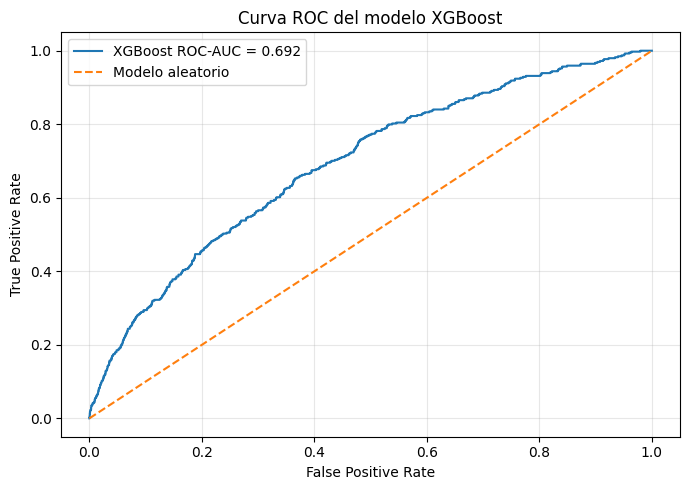

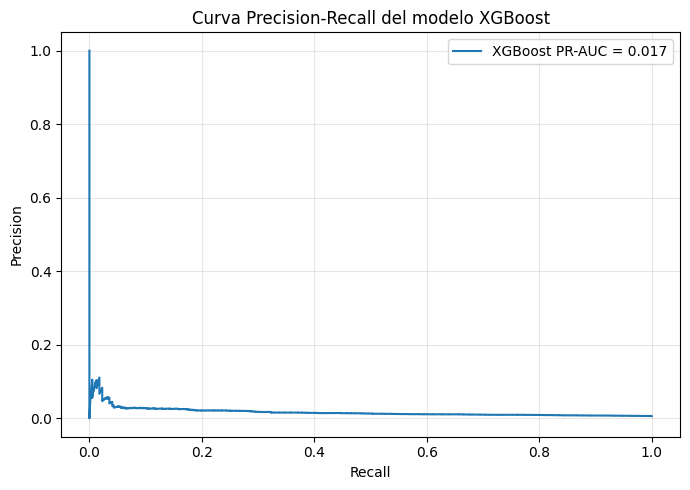


===== TOP THRESHOLDS POR F1 =====
    threshold  accuracy  precision    recall        f1  falsos_positivos  \
61       0.71  0.958341   0.026094  0.157360  0.044765              2314   
64       0.74  0.968780   0.027365  0.116751  0.044337              1635   
63       0.73  0.965379   0.026744  0.129442  0.044329              1856   
62       0.72  0.961962   0.026242  0.142132  0.044304              2078   
60       0.70  0.954090   0.025226  0.170051  0.043934              2589   
67       0.77  0.977486   0.029091  0.081218  0.042838              1068   
66       0.76  0.974668   0.027972  0.091371  0.042832              1251   
65       0.75  0.971566   0.026810  0.101523  0.042418              1452   
74       0.84  0.989940   0.051282  0.035533  0.041979               259   
59       0.69  0.949855   0.023558  0.175127  0.041529              2860   

    falsos_negativos  verdaderos_positivos  
61               332                    62  
64               348                  

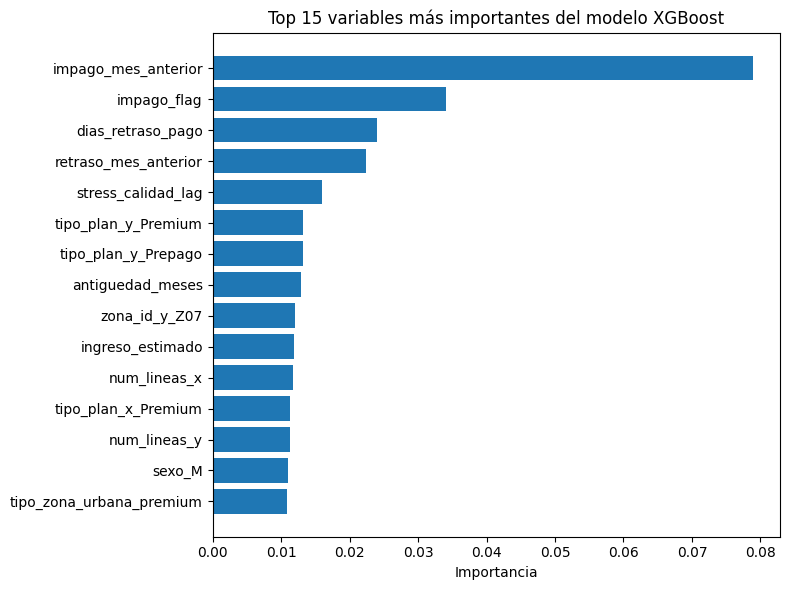


Archivos exportados:
- comparacion_modelos_churn.csv
- analisis_thresholds_churn.csv
- importancia_variables_xgboost.csv


In [13]:
# ============================================================
# BLOQUE PARA SUBIR NOTA — EVALUACIÓN PROFESIONAL DEL MODELO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report,
    roc_curve, precision_recall_curve
)

# ============================================================
# 1. BENCHMARK — REGRESIÓN LOGÍSTICA
# ============================================================

benchmark = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

benchmark.fit(X_train, y_train)

proba_benchmark = benchmark.predict_proba(X_test)[:, 1]
pred_benchmark = (proba_benchmark >= 0.5).astype(int)

print("===== BENCHMARK: REGRESIÓN LOGÍSTICA =====")
print("Accuracy:", round(accuracy_score(y_test, pred_benchmark) * 100, 2))
print("Precision:", round(precision_score(y_test, pred_benchmark, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, pred_benchmark, zero_division=0), 4))
print("F1:", round(f1_score(y_test, pred_benchmark, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_benchmark), 4))
print("PR-AUC:", round(average_precision_score(y_test, proba_benchmark), 4))
print(confusion_matrix(y_test, pred_benchmark))


# ============================================================
# 2. COMPARACIÓN CON MODELO FINAL XGBOOST
# ============================================================

# Usa tu threshold final
threshold_final = 0.70

pred_xgb = (y_proba >= threshold_final).astype(int)

comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística Benchmark", "XGBoost Final"],
    "Accuracy": [
        accuracy_score(y_test, pred_benchmark),
        accuracy_score(y_test, pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, pred_benchmark, zero_division=0),
        precision_score(y_test, pred_xgb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, pred_benchmark, zero_division=0),
        recall_score(y_test, pred_xgb, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, pred_benchmark, zero_division=0),
        f1_score(y_test, pred_xgb, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, proba_benchmark),
        roc_auc_score(y_test, y_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_test, proba_benchmark),
        average_precision_score(y_test, y_proba)
    ]
})

print("\n===== COMPARACIÓN FINAL DE MODELOS =====")
print(comparacion)


# ============================================================
# 3. CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC del modelo XGBoost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. CURVA PRECISION-RECALL
# ============================================================

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"XGBoost PR-AUC = {average_precision_score(y_test, y_proba):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall del modelo XGBoost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 5. ANÁLISIS DE THRESHOLDS
# ============================================================

thresholds = np.arange(0.10, 0.91, 0.01)
resultados_threshold = []

for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    
    resultados_threshold.append({
        "threshold": round(t, 2),
        "accuracy": accuracy_score(y_test, pred_t),
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "falsos_positivos": confusion_matrix(y_test, pred_t)[0, 1],
        "falsos_negativos": confusion_matrix(y_test, pred_t)[1, 0],
        "verdaderos_positivos": confusion_matrix(y_test, pred_t)[1, 1]
    })

df_thresholds = pd.DataFrame(resultados_threshold)

print("\n===== TOP THRESHOLDS POR F1 =====")
print(df_thresholds.sort_values("f1", ascending=False).head(10))

print("\n===== THRESHOLDS DEFENDIBLES: ACCURACY >= 0.90 Y RECALL >= 0.20 =====")
print(
    df_thresholds[
        (df_thresholds["accuracy"] >= 0.90) &
        (df_thresholds["recall"] >= 0.20)
    ].sort_values("f1", ascending=False).head(10)
)


# ============================================================
# 6. MATRIZ FINAL Y ANÁLISIS DE ERRORES
# ============================================================

cm = confusion_matrix(y_test, pred_xgb)

tn, fp, fn, tp = cm.ravel()

print("\n===== MATRIZ DE CONFUSIÓN FINAL =====")
print(cm)

print("\nInterpretación:")
print("Verdaderos negativos:", tn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", tp)

print("\nPorcentaje de churners detectados:")
print(round(tp / (tp + fn) * 100, 2), "%")

print("\nPorcentaje de falsas alarmas sobre clientes marcados como churn:")
print(round(fp / (fp + tp) * 100, 2), "%")


# ============================================================
# 7. TOP VARIABLES IMPORTANTES
# ============================================================

importancias = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": model.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n===== TOP 15 VARIABLES MÁS IMPORTANTES =====")
print(importancias.head(15))

plt.figure(figsize=(8, 6))
top_vars = importancias.head(15).sort_values("importancia")
plt.barh(top_vars["variable"], top_vars["importancia"])
plt.xlabel("Importancia")
plt.title("Top 15 variables más importantes del modelo XGBoost")
plt.tight_layout()
plt.show()


# ============================================================
# 8. EXPORTAR RESULTADOS PARA EL TFM
# ============================================================

comparacion.to_csv("comparacion_modelos_churn.csv", index=False)
df_thresholds.to_csv("analisis_thresholds_churn.csv", index=False)
importancias.to_csv("importancia_variables_xgboost.csv", index=False)

print("\nArchivos exportados:")
print("- comparacion_modelos_churn.csv")
print("- analisis_thresholds_churn.csv")
print("- importancia_variables_xgboost.csv")